In [1]:
import os, json, glob, time, gc
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment

DEVICE = 'cpu'
N_GPUS = 0
if torch.cuda.is_available():
    try:
        _p = nn.Conv2d(1, 1, 3).cuda()
        _ = _p(torch.zeros(1, 1, 8, 8, device='cuda')).cpu()
        del _p
        DEVICE = 'cuda'
        N_GPUS = torch.cuda.device_count()
    except Exception as e:
        print(f'GPU unusable: {str(e)[:80]} -> CPU')

print(f'Device: {DEVICE} | GPUs: {N_GPUS} | PyTorch: {torch.__version__}')
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} | {props.total_memory/1e9:.1f}GB')

CAND = [
    '/kaggle/input/competitions/biohub-cell-tracking-during-development',
    '/kaggle/input/biohub-cell-tracking-during-development',
]
ROOT = next((p for p in CAND if Path(p, 'train').exists()), None)
if ROOT is None:
    raise FileNotFoundError(f'Data not found. Checked: {CAND}')
TRAIN_DIR = Path(ROOT) / 'train'
TEST_DIR  = Path(ROOT) / 'test'
OUT_DIR   = Path('/kaggle/working')
CKPT_PATH = OUT_DIR / 'unet2d.pt'

POOL         = 4        # XY block-pool factor
BASE         = 32       # wider than 3D version -- 2D is much cheaper per layer
EPOCHS       = 30
SPF          = 8        # slices per frame to cache -- sample multiple Z per timepoint
FPM          = 12       # frames per movie
BATCH        = 64 * max(N_GPUS, 1)   # 2D allows much larger batches
LR           = 2e-4
SEED         = 42

# target generation
GAUSS_SIGMA  = 2.0      # voxels in pooled XY grid -- tighter than 3D version
                         # because in 2D a nucleus is a proper local peak,
                         # not smeared across Z slices

# detection
DETECT_THRESH = 0.20    # starting point for sweep -- higher than before
                         # because 2D predictions should be sharper

# positive-unlabelled weights -- back to BCE (focal made things worse)
W_POS  = 15.0
W_BG   = 1.0
W_IGN  = 0.02

TEST4 = ['6bba_05b6850b', '6bba_05db0fb1', '44b6_0113de3b', '44b6_0b24845f']

RNG = np.random.default_rng(SEED)
torch.manual_seed(SEED)
print(f'Batch: {BATCH} | LR: {LR} | Sigma: {GAUSS_SIGMA} | 2D mode')

Device: cuda | GPUs: 2 | PyTorch: 2.10.0+cu128
  GPU 0: Tesla T4 | 15.6GB
  GPU 1: Tesla T4 | 15.6GB
Batch: 128 | LR: 0.0002 | Sigma: 2.0 | 2D mode


In [2]:
def _block2d(ci, co):
    return nn.Sequential(
        nn.Conv2d(ci, co, 3, padding=1),
        nn.BatchNorm2d(co),
        nn.ReLU(inplace=True),
        nn.Conv2d(co, co, 3, padding=1),
        nn.BatchNorm2d(co),
        nn.ReLU(inplace=True),
    )

class UNet2D(nn.Module):
    """
    2D U-Net: (B, 1, H, W) -> heatmap logits (B, 1, H, W).
    Two pooling levels only -- keeps receptive field local enough
    to distinguish individual nuclei rather than learning tissue-level
    structure, which was the confirmed failure mode of the 3D version.
    """
    def __init__(self, base=BASE):
        super().__init__()
        b = base
        self.e1   = _block2d(1,   b)
        self.e2   = _block2d(b,   b*2)
        self.pool = nn.MaxPool2d(2)
        self.bn   = _block2d(b*2, b*4)
        self.u2   = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.d2   = _block2d(b*4, b*2)
        self.u1   = nn.ConvTranspose2d(b*2, b,   2, stride=2)
        self.d1   = _block2d(b*2, b)
        self.out  = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        b  = self.bn(self.pool(e2))
        d2 = self.d2(torch.cat([self.u2(b),  e2], 1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], 1))
        return self.out(d1)

model = UNet2D(base=BASE).to(DEVICE)
if N_GPUS > 1:
    model = nn.DataParallel(model, device_ids=list(range(N_GPUS)))
    print(f'DataParallel across {N_GPUS} GPUs')

n_params = sum(p.numel() for p in model.parameters())
print(f'UNet2D params: {n_params:,}')

with torch.no_grad():
    _t = torch.zeros(2, 1, 64, 64, device=DEVICE)
    _o = model(_t)
    assert _o.shape == _t.shape, f'Shape mismatch: {_o.shape}'
    print(f'Forward OK: {tuple(_t.shape)} -> {tuple(_o.shape)}')
    del _t, _o

DataParallel across 2 GPUs
UNet2D params: 467,233
Forward OK: (2, 1, 64, 64) -> (2, 1, 64, 64)


In [3]:
_ZC = {}

def read_meta(zp):
    with open(Path(zp)/'0'/'zarr.json') as f:
        m = json.load(f)
    return dict(shape=tuple(m['shape']), dtype=np.dtype(m['data_type']))

def load_vol(zp, t, meta=None):
    try:
        import zarr
        k = str(zp)
        if k not in _ZC:
            _ZC[k] = zarr.open(k, mode='r')['0']
        return np.asarray(_ZC[k][t])
    except Exception:
        import blosc2
        if meta is None:
            meta = read_meta(zp)
        buf = blosc2.decompress(open(Path(zp)/'0'/'c'/str(t)/'0'/'0'/'0','rb').read())
        return np.frombuffer(buf, dtype=meta['dtype']).reshape(meta['shape'][1:])

def pool_xy(vol, f=POOL):
    Z, Y, X = vol.shape
    Y2, X2 = (Y//f)*f, (X//f)*f
    v = vol[:, :Y2, :X2].astype(np.float32, copy=False)
    return v.reshape(Z, Y2//f, f, X2//f, f).mean(axis=(2, 4))

def normalize_slice(slc):
    """Per-slice robust normalization. Clip to [p2, p99] then scale to [0,1]."""
    lo = float(np.percentile(slc, 2.0))
    hi = float(np.percentile(slc, 99.0))
    if hi <= lo:
        return np.zeros_like(slc, dtype=np.float32)
    return np.clip((slc - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)

def read_geff_nodes(geff_path):
    try:
        import zarr
        root = zarr.open(str(geff_path), mode='r')
        cols = [np.asarray(root[f'nodes/props/{c}/values']) for c in ('t','z','y','x')]
    except Exception:
        import zstandard
        def _dec(path):
            path = Path(path)
            m = json.load(open(path/'zarr.json'))
            dt = np.dtype(m['data_type']); n = int(m['shape'][0])
            buf = zstandard.ZstdDecompressor().decompress(open(path/'c'/'0','rb').read())
            return np.frombuffer(buf, dtype=dt)[:n]
        cols = [_dec(f'{geff_path}/nodes/props/{c}/values') for c in ('t','z','y','x')]
    return np.stack(cols, axis=1).astype(np.float64)

In [4]:
def all_movies():
    zarr_names = {Path(p).name[:-5] for p in glob.glob(f'{TRAIN_DIR}/*.zarr')}
    geff_names = {Path(p).name[:-5] for p in glob.glob(f'{TRAIN_DIR}/*.geff')}
    return sorted(zarr_names & geff_names)

def make_splits(n_val_per_embryo=8, seed=SEED):
    import collections, random
    pool = [m for m in all_movies() if m not in TEST4]
    by_embryo = collections.defaultdict(list)
    for m in pool:
        by_embryo[m.split('_')[0]].append(m)
    rng = random.Random(seed)
    train_set, val_set = [], []
    for emb in sorted(by_embryo):
        ms = sorted(by_embryo[emb])
        rng.shuffle(ms)
        val_set.extend(ms[:n_val_per_embryo])
        train_set.extend(ms[n_val_per_embryo:])
    return train_set, val_set

train_movies, val_movies = make_splits(n_val_per_embryo=8)
print(f'Train: {len(train_movies)} | Val: {len(val_movies)} | Test4 held out: {len(TEST4)}')

Train: 179 | Val: 16 | Test4 held out: 4


In [5]:
def load_movie_slices(ds, fpm, spf):
    """
    Returns list of (slice_2d [H,W] f32 normalized, pts_2d Nx2 [y,x] pooled coords).
    Only caches slices that have at least one GT annotation in them.
    Slices without annotations are entirely background -- not useful for
    teaching the model to find cell centres, only for teaching it to
    suppress false positives, which the loss weights already handle.
    """
    zp   = str(TRAIN_DIR / f'{ds}.zarr')
    gp   = str(TRAIN_DIR / f'{ds}.geff')
    meta = read_meta(zp)
    nodes = read_geff_nodes(gp)   # (N, 4): t, z, y, x

    node_t = nodes[:, 0].round().astype(int)
    node_z = nodes[:, 1].round().astype(int)

    # sample fpm timepoints that have GT annotations
    ann_t = sorted(set(node_t.tolist()) & set(range(meta['shape'][0])))
    if not ann_t:
        return []
    t_idx = np.linspace(0, len(ann_t)-1, min(fpm, len(ann_t))).round().astype(int)
    chosen_t = sorted(set(ann_t[i] for i in t_idx))

    out = []
    for t in chosen_t:
        vol  = load_vol(zp, t, meta)
        pvol = pool_xy(vol)          # (Z, H/4, W/4)

        # GT annotations at this timepoint
        mask_t = node_t == t
        ann_z  = node_z[mask_t]
        ann_y  = nodes[mask_t, 2]
        ann_x  = nodes[mask_t, 3]

        # sample spf Z-slices that actually contain annotations
        ann_z_unique = sorted(set(ann_z.tolist()))
        z_idx = np.linspace(0, len(ann_z_unique)-1, min(spf, len(ann_z_unique))).round().astype(int)
        chosen_z = sorted(set(ann_z_unique[i] for i in z_idx))

        for z in chosen_z:
            slc_norm = normalize_slice(pvol[z])     # (H/4, W/4) in [0,1]

            # GT points IN THIS Z-SLICE ONLY
            # This is the fix for the Z-alignment issue: in 3D training,
            # a GT point at z=30 was stamped as a 3D Gaussian visible
            # at z=28,29,30,31,32 -- the model saw the blob "everywhere"
            # and learned tissue-level structure.
            # In 2D, each slice only has GT points whose annotated Z
            # matches this slice exactly. Sharp, unambiguous targets.
            in_slice = ann_z == z
            pts_y = ann_y[in_slice] / POOL     # scale to pooled grid
            pts_x = ann_x[in_slice] / POOL
            pts   = np.stack([pts_y, pts_x], axis=1).astype(np.float32)

            out.append((slc_norm, pts))
    return out

t0 = time.time()
train_cache = []
for i, ds in enumerate(train_movies):
    train_cache += load_movie_slices(ds, FPM, SPF)
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{len(train_movies)} movies, {len(train_cache)} slices ({time.time()-t0:.0f}s)')

print(f'Train cache: {len(train_cache)} slices | {time.time()-t0:.0f}s')

val_cache = []
for ds in val_movies:
    val_cache += load_movie_slices(ds, fpm=4, spf=4)
print(f'Val cache: {len(val_cache)} slices')

assert len(train_cache) > 0, 'No slices cached -- check paths and GT reader'
total_bytes = sum(s[0].nbytes for s in train_cache)
print(f'RAM used: ~{total_bytes/1e6:.1f} MB')

  20/179 movies, 651 slices (36s)
  40/179 movies, 1181 slices (71s)
  60/179 movies, 1954 slices (104s)
  80/179 movies, 3432 slices (134s)
  100/179 movies, 5023 slices (161s)
  120/179 movies, 6654 slices (189s)
  140/179 movies, 8178 slices (215s)
  160/179 movies, 9642 slices (240s)
Train cache: 11134 slices | 265s
Val cache: 203 slices
RAM used: ~182.4 MB


In [6]:
def stamp_heatmap_2d(shape, pts, sigma=GAUSS_SIGMA):
    """2D Gaussian heatmap. One blob per GT point, max-composite."""
    hm = np.zeros(shape, np.float32)
    r  = int(np.ceil(3 * sigma))
    yy, xx = np.mgrid[-r:r+1, -r:r+1]
    g  = np.exp(-(yy**2 + xx**2) / (2 * sigma**2)).astype(np.float32)
    H, W = shape
    for cy, cx in pts:
        cy, cx = int(round(cy)), int(round(cx))
        y0, y1 = max(0, cy-r), min(H, cy+r+1)
        x0, x1 = max(0, cx-r), min(W, cx+r+1)
        gy = y0-(cy-r); gx = x0-(cx-r)
        sub = g[gy:gy+(y1-y0), gx:gx+(x1-x0)]
        np.maximum(hm[y0:y1, x0:x1], sub, out=hm[y0:y1, x0:x1])
    return hm

def build_sample_2d(slc, pts, augment=True):
    """
    Returns (input [1,H,W], target [1,H,W], weight [1,H,W]) as float32.
    Weight scheme:
      - GT centroid region (heatmap > 0.05): W_POS = 15
      - Dark background (< p40):             W_BG  = 1
      - Bright but unannotated:              W_IGN = 0.02
    """
    x   = slc.copy()
    tgt = stamp_heatmap_2d(x.shape, pts)

    if augment:
        # horizontal flip
        if RNG.random() < 0.5:
            x   = np.fliplr(x).copy()
            tgt = np.fliplr(tgt).copy()
        # vertical flip
        if RNG.random() < 0.5:
            x   = np.flipud(x).copy()
            tgt = np.flipud(tgt).copy()
        # 90-degree rotation (k times)
        k = RNG.integers(0, 4)
        if k > 0:
            x   = np.rot90(x,   k).copy()
            tgt = np.rot90(tgt, k).copy()

    w = np.full(tgt.shape, W_IGN, np.float32)
    w[x < np.quantile(x, 0.40)] = W_BG
    w[tgt > 0.05]               = W_POS

    return x[None], tgt[None], w[None]   # add channel dim

bce_loss = nn.BCEWithLogitsLoss(reduction='none')

In [7]:
from skimage.feature import peak_local_max

def compute_val_metrics(model, val_cache, tol=2.5):
    model.eval()
    # extended downward -- best_thresh=0.10 every epoch means 0.10 is still
    # not the true optimum, real peak is likely below 0.10
    THRESHOLDS = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
    hits       = {t: 0 for t in THRESHOLDS}
    totals     = {t: 0 for t in THRESHOLDS}
    peak_counts = {t: [] for t in THRESHOLDS}   # NEW: track how many peaks per slice
    val_loss_sum = 0.0; val_loss_n = 0

    with torch.no_grad():
        for slc, pts in val_cache:
            xt     = torch.from_numpy(slc[None, None]).to(DEVICE, non_blocking=True)
            logits = model(xt)
            hm     = torch.sigmoid(logits)[0, 0].float().cpu().numpy()

            tgt_np = stamp_heatmap_2d(slc.shape, pts)
            w_np   = np.full(tgt_np.shape, W_IGN, np.float32)
            w_np[slc < np.quantile(slc, 0.40)] = W_BG
            w_np[tgt_np > 0.05] = W_POS
            yb = torch.from_numpy(tgt_np[None, None]).to(DEVICE, non_blocking=True)
            wb = torch.from_numpy(w_np[None, None]).to(DEVICE, non_blocking=True)
            vloss = (bce_loss(logits, yb) * wb).sum() / wb.sum()
            val_loss_sum += float(vloss); val_loss_n += 1

            for thresh in THRESHOLDS:
                pk = peak_local_max(
                    hm, min_distance=3, threshold_abs=thresh, exclude_border=False
                ).astype(np.float32)
                peak_counts[thresh].append(len(pk))
                for p in pts:
                    totals[thresh] += 1
                    if len(pk) and np.min(np.linalg.norm(pk - p, axis=1)) <= tol:
                        hits[thresh] += 1

    recalls     = {t: hits[t]/max(totals[t], 1) for t in THRESHOLDS}
    avg_peaks   = {t: np.mean(peak_counts[t]) for t in THRESHOLDS}
    best_thresh = max(recalls, key=recalls.get)
    model.train()
    return recalls[best_thresh], val_loss_sum/max(val_loss_n,1), best_thresh, recalls, avg_peaks

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)


def unwrap_state_dict(m):
    return m.module.state_dict() if isinstance(m, nn.DataParallel) else m.state_dict()


best_recall = -1.0
best_state = None
best_thresh_final = 0.10

n = len(train_cache)
t_start = time.time()
history = []

for epoch in range(EPOCHS):

    model.train()

    perm = RNG.permutation(n)

    epoch_loss = 0.0
    n_steps = 0

    for i in range(0, n, BATCH):

        idx = perm[i:i+BATCH]

        samples = [
            build_sample_2d(*train_cache[j], augment=True)
            for j in idx
        ]

        bs = len(samples)

        xb = torch.from_numpy(
            np.stack([s[0] for s in samples])
        ).to(
            DEVICE,
            non_blocking=True
        )

        yb = torch.from_numpy(
            np.stack([s[1] for s in samples])
        ).to(
            DEVICE,
            non_blocking=True
        )

        wb = torch.from_numpy(
            np.stack([s[2] for s in samples])
        ).to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        logits = model(xb)

        loss = (
            bce_loss(logits, yb) * wb
        ).sum() / wb.sum()

        loss.backward()

        optimizer.step()

        epoch_loss += float(loss.detach()) * bs

        n_steps += 1

    scheduler.step()

    avg_train = epoch_loss / max(n_steps * BATCH, 1)

    recall, avg_val, best_thresh, all_recalls, avg_peaks = compute_val_metrics(
        model,
        val_cache
    )

    elapsed = (time.time() - t_start) / 60

    improved = recall > best_recall

    if improved:

        best_recall = recall

        best_thresh_final = best_thresh

        best_state = {
            k: v.cpu().clone()
            for k, v in unwrap_state_dict(model).items()
        }

        tag = " <- BEST"

    else:

        tag = ""

    history.append({

        "epoch": epoch + 1,

        "train_loss": avg_train,

        "val_loss": avg_val,

        "val_recall": recall,

        "best_thresh": best_thresh

    })

    print(
        f"Epoch {epoch+1:2d}/{EPOCHS} | "
        f"train_loss={avg_train:.4f} | "
        f"val_loss={avg_val:.4f} | "
        f"val_recall={recall:.3f}@{best_thresh:.2f} | "
        f"{elapsed:.1f} min{tag}"
    )

    sweep_str = "  ".join(

        f"{t:.2f}:r={r:.3f}/pk={avg_peaks[t]:.0f}"

        for t, r in sorted(all_recalls.items())

    )

    print("Threshold sweep:")

    print(sweep_str)

    # --------------------------------------------------
    # Visualization
    # --------------------------------------------------

    if len(val_cache):

        try:

            vis_samples = [

                val_cache[i]

                for i in np.linspace(

                    0,

                    len(val_cache) - 1,

                    4,

                    dtype=int

                )

            ]

            fig, axes = plt.subplots(

                4,

                4,

                figsize=(18,20)

            )

            with torch.no_grad():

                for row, (slc, pts) in enumerate(vis_samples):

                    xt = torch.from_numpy(

                        slc[None,None]

                    ).to(DEVICE)

                    hm = torch.sigmoid(

                        model(xt)

                    )[0,0].cpu().numpy()

                    tgt = stamp_heatmap_2d(

                        slc.shape,

                        pts

                    )

                    pk = peak_local_max(

                        hm,

                        min_distance=3,

                        threshold_abs=best_thresh,

                        exclude_border=False

                    )

                    axes[row,0].imshow(

                        slc,

                        cmap="gray",

                        vmin=0,

                        vmax=1

                    )

                    axes[row,0].set_title("Input")

                    axes[row,1].imshow(

                        tgt,

                        cmap="hot",

                        vmin=0,

                        vmax=1

                    )

                    for cy, cx in pts:

                        axes[row,1].plot(

                            cx,

                            cy,

                            "g+",

                            ms=8

                        )

                    axes[row,1].set_title(

                        f"GT ({len(pts)})"

                    )

                    im = axes[row,2].imshow(

                        hm,

                        cmap="hot",

                        vmin=0,

                        vmax=1

                    )

                    axes[row,2].set_title(

                        f"Pred max={hm.max():.3f}"

                    )

                    plt.colorbar(

                        im,

                        ax=axes[row,2]

                    )

                    axes[row,3].imshow(

                        hm,

                        cmap="gray",

                        vmin=0,

                        vmax=1

                    )

                    if len(pk):

                        axes[row,3].scatter(

                            pk[:,1],

                            pk[:,0],

                            c="red",

                            s=12,

                            label=f"Pred {len(pk)}"

                        )

                    if len(pts):

                        axes[row,3].scatter(

                            pts[:,1],

                            pts[:,0],

                            c="lime",

                            s=30,

                            marker="+",

                            label=f"GT {len(pts)}"

                        )

                    axes[row,3].legend(fontsize=7)

                    axes[row,3].set_title(

                        f"Peaks @{best_thresh:.2f}"

                    )

            fig.suptitle(

                f"Epoch {epoch+1} | Recall={recall:.3f}",

                fontsize=14

            )

            plt.tight_layout()

            vis_path = OUT_DIR / f"vis_epoch_{epoch+1:02d}.png"

            plt.savefig(

                vis_path,

                dpi=80,

                bbox_inches="tight"

            )

            plt.close(fig)

            print(f"Saved visualization: {vis_path}")

        except Exception as e:

            print(e)

    # --------------------------------------------------
    # Save BEST model
    # --------------------------------------------------

    if improved:

        torch.save(

            {

                "state_dict": best_state,

                "arch": "UNet2D",

                "base": BASE,

                "pool": POOL,

                "gauss_sigma": GAUSS_SIGMA,

                "detect_thresh": best_thresh_final,

                "val_recall": best_recall,

                "epoch": epoch + 1,

            },

            CKPT_PATH

        )

        print("Best checkpoint updated.")

    # --------------------------------------------------
    # Save EVERY epoch
    # --------------------------------------------------

    torch.save(

        {

            "epoch": epoch + 1,

            "state_dict": unwrap_state_dict(model),

            "optimizer": optimizer.state_dict(),

            "scheduler": scheduler.state_dict(),

            "train_loss": avg_train,

            "val_loss": avg_val,

            "val_recall": recall,

            "best_thresh": best_thresh,

        },

        OUT_DIR / f"checkpoint_epoch_{epoch+1:02d}.pth"

    )

    pd.DataFrame(history).to_csv(

        OUT_DIR / "training_history.csv",

        index=False

    )



print()

print("=" * 60)

print(f"Best validation recall : {best_recall:.4f}")

print(f"Best threshold         : {best_thresh_final:.2f}")

print(f"History saved          : {OUT_DIR/'training_history.csv'}")

print("=" * 60)

Epoch  1/30 | train_loss=0.6399 | val_loss=0.5373 | val_recall=0.784@0.05 | 0.3 min <- BEST
Threshold sweep:
0.05:r=0.784/pk=48  0.08:r=0.784/pk=48  0.10:r=0.784/pk=48  0.15:r=0.784/pk=48  0.20:r=0.784/pk=48  0.25:r=0.784/pk=48  0.30:r=0.784/pk=48  0.35:r=0.784/pk=48  0.40:r=0.784/pk=43  0.45:r=0.784/pk=40  0.50:r=0.784/pk=35
Saved visualization: /kaggle/working/vis_epoch_01.png
Best checkpoint updated.
Epoch  2/30 | train_loss=0.5010 | val_loss=0.4628 | val_recall=0.833@0.05 | 0.5 min <- BEST
Threshold sweep:
0.05:r=0.833/pk=47  0.08:r=0.833/pk=47  0.10:r=0.833/pk=47  0.15:r=0.833/pk=47  0.20:r=0.833/pk=47  0.25:r=0.833/pk=46  0.30:r=0.833/pk=40  0.35:r=0.833/pk=37  0.40:r=0.833/pk=36  0.45:r=0.833/pk=36  0.50:r=0.833/pk=35
Saved visualization: /kaggle/working/vis_epoch_02.png
Best checkpoint updated.
Epoch  3/30 | train_loss=0.4415 | val_loss=0.4348 | val_recall=0.838@0.05 | 0.8 min <- BEST
Threshold sweep:
0.05:r=0.838/pk=48  0.08:r=0.838/pk=48  0.10:r=0.838/pk=48  0.15:r=0.838/pk=4

In [10]:
torch.save({
    'state_dict':      best_state if best_state else unwrap_state_dict(model),
    'arch':            'UNet2D',
    'base':            BASE,
    'pool':            POOL,
    'gauss_sigma':     GAUSS_SIGMA,
    'detect_thresh':   best_thresh_final,
    'val_recall':      best_recall,
    'n_train_movies':  len(train_movies),
    'epochs_trained':  epoch + 1,
}, CKPT_PATH)
print(f'Saved: {CKPT_PATH} | recall={best_recall:.4f} @ thresh={best_thresh_final}')

ck = torch.load(CKPT_PATH, map_location='cpu')
m2 = UNet2D(base=ck['base'])
m2.load_state_dict(ck['state_dict'])
m2.eval()
with torch.no_grad():
    y = m2(torch.zeros(1, 1, 64, 64))
assert tuple(y.shape) == (1, 1, 64, 64)
print(f'Reload OK: {tuple(y.shape)}')

Saved: /kaggle/working/unet2d.pt | recall=0.8784 @ thresh=0.05
Reload OK: (1, 1, 64, 64)


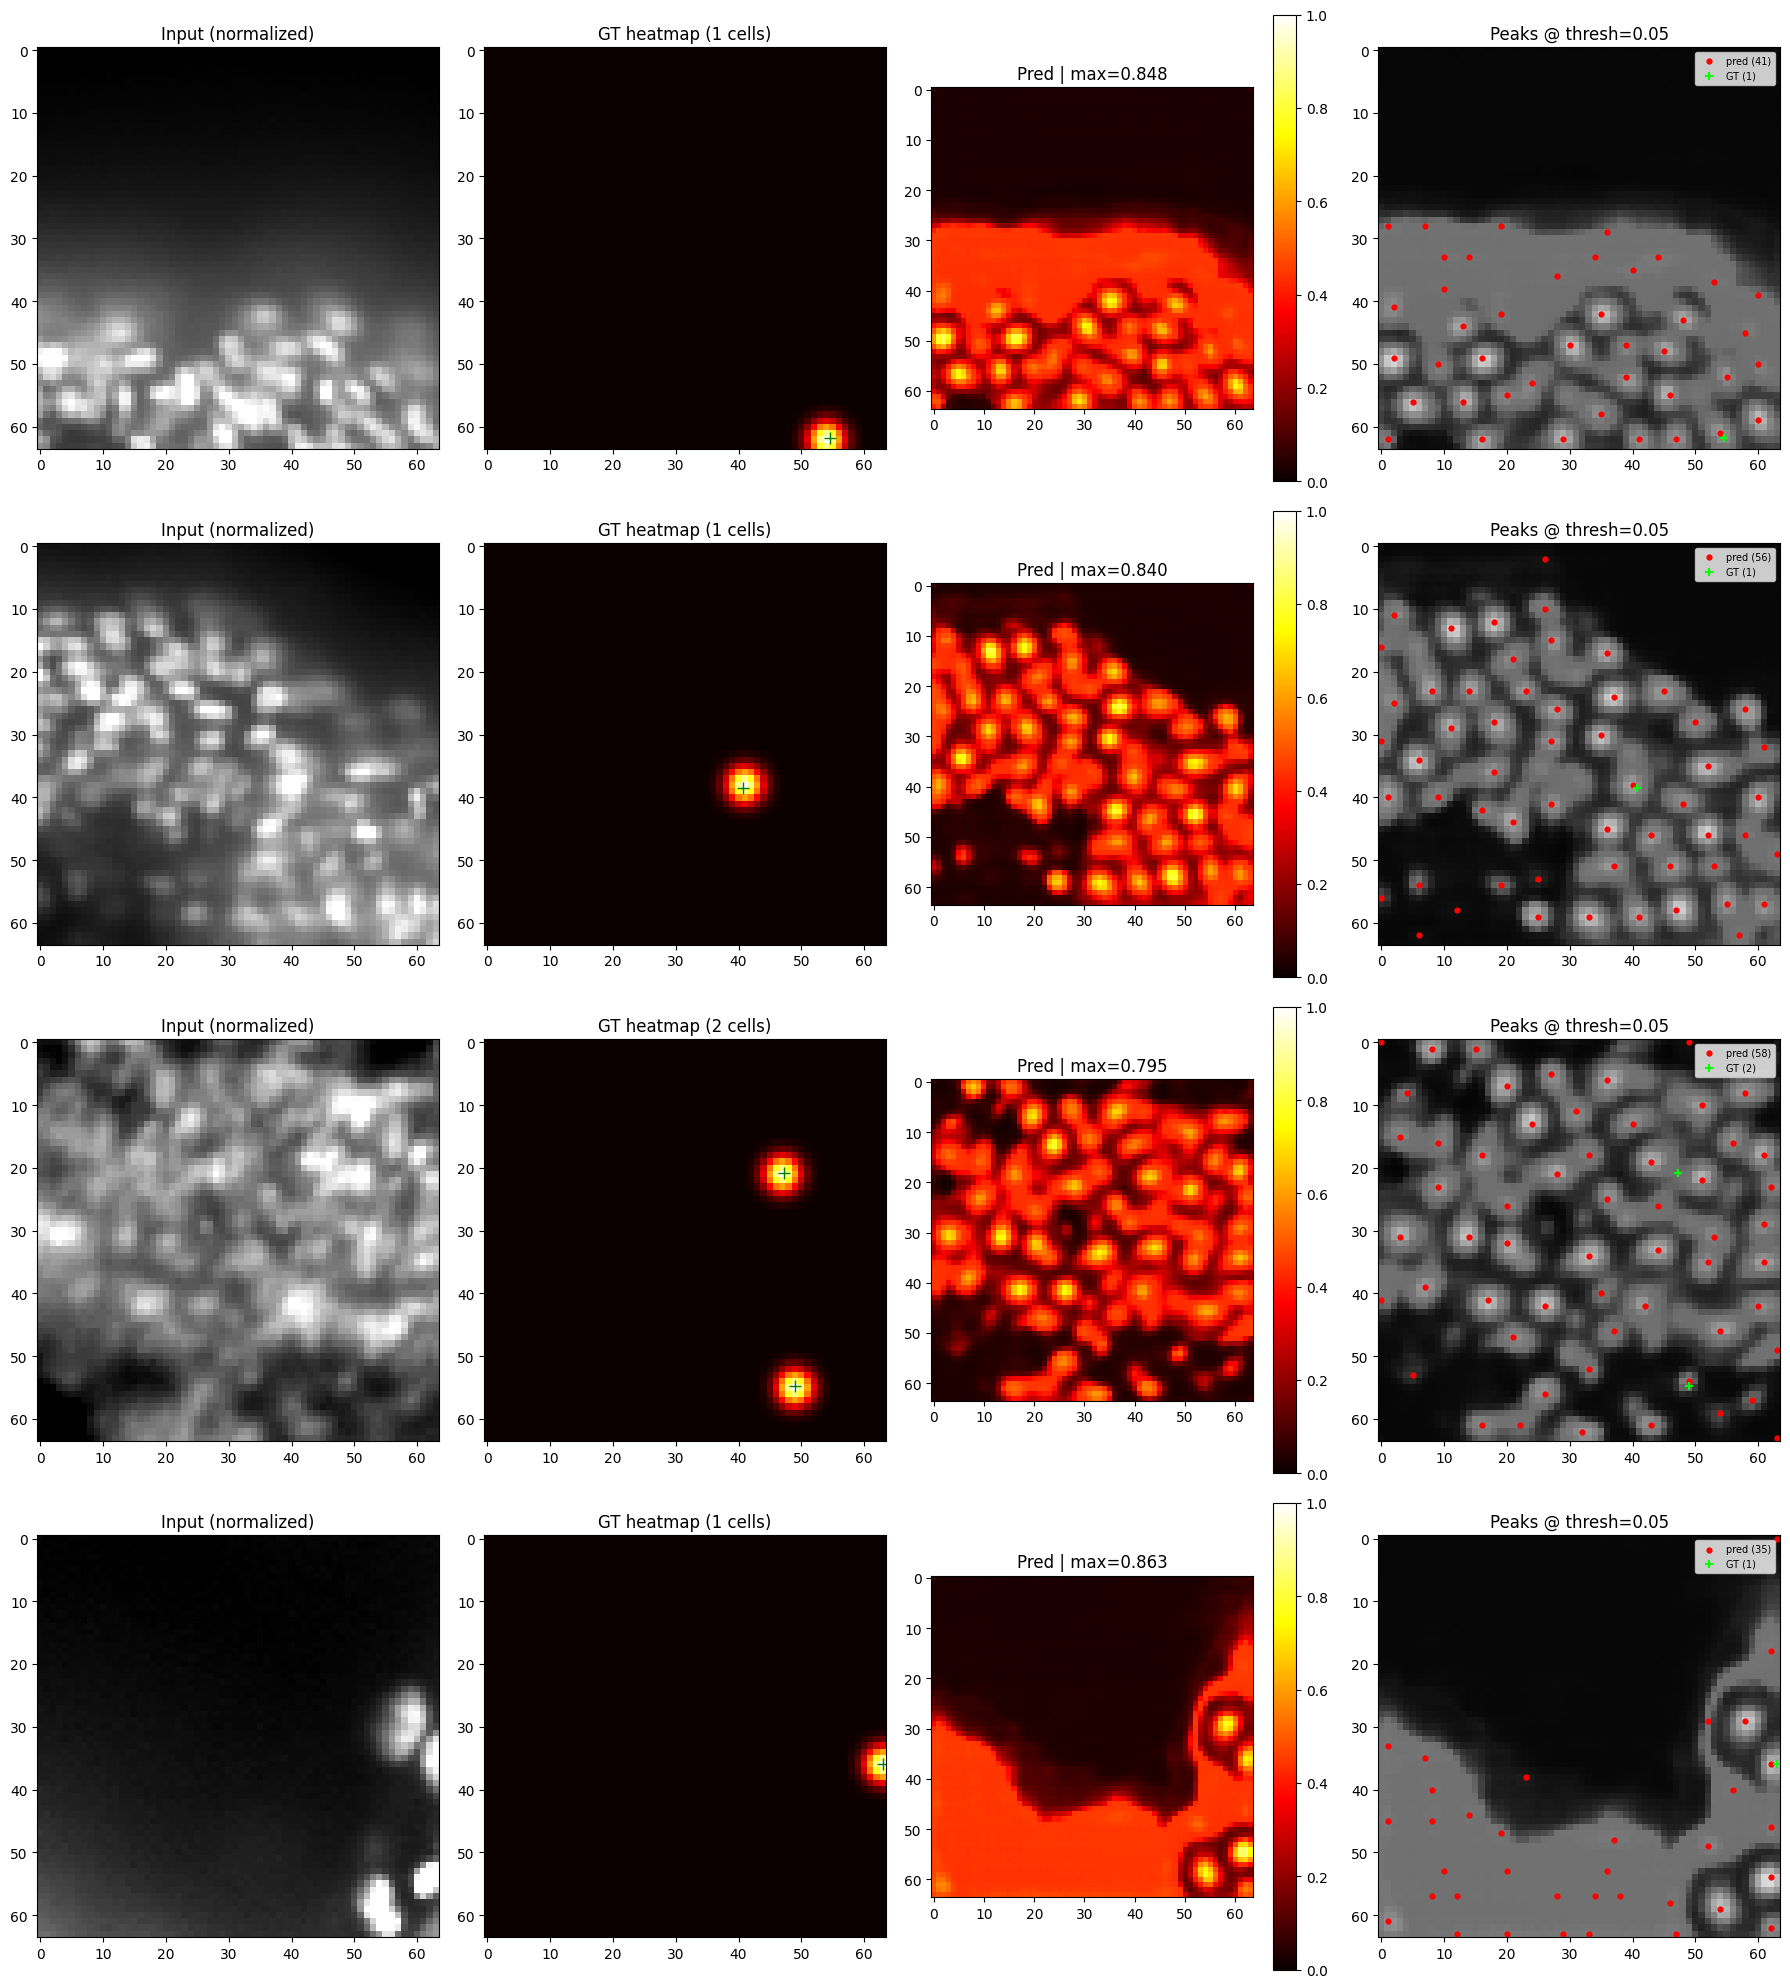

Saved: /kaggle/working/val_predictions_2d.png


In [11]:
import matplotlib.pyplot as plt

def visualize_val_2d(model, val_cache, n_samples=4, thresh=None):
    if thresh is None:
        thresh = best_thresh_final
    model.eval()
    fig, axes = plt.subplots(n_samples, 4, figsize=(18, 5*n_samples))
    if n_samples == 1:
        axes = axes[None]

    samples = [val_cache[i] for i in np.linspace(0, len(val_cache)-1, n_samples, dtype=int)]
    with torch.no_grad():
        for row, (slc, pts) in enumerate(samples):
            xt  = torch.from_numpy(slc[None, None]).to(DEVICE)
            hm  = torch.sigmoid(model(xt))[0,0].cpu().numpy()
            tgt = stamp_heatmap_2d(slc.shape, pts)

            axes[row,0].imshow(slc, cmap='gray', vmin=0, vmax=1)
            axes[row,0].set_title(f'Input (normalized)')

            axes[row,1].imshow(tgt, cmap='hot', vmin=0, vmax=1)
            for cy, cx in pts:
                axes[row,1].plot(cx, cy, 'g+', ms=8)
            axes[row,1].set_title(f'GT heatmap ({len(pts)} cells)')

            im = axes[row,2].imshow(hm, cmap='hot', vmin=0, vmax=1)
            axes[row,2].set_title(f'Pred | max={hm.max():.3f}')
            plt.colorbar(im, ax=axes[row,2])

            pk = peak_local_max(hm, min_distance=3,
                                threshold_abs=thresh, exclude_border=False)
            axes[row,3].imshow(hm, cmap='gray', vmin=0, vmax=1)
            if len(pk):
                axes[row,3].scatter(pk[:,1], pk[:,0], c='red', s=12, label=f'pred ({len(pk)})')
            if len(pts):
                axes[row,3].scatter(pts[:,1], pts[:,0], c='lime', s=30, marker='+',
                                    label=f'GT ({len(pts)})')
            axes[row,3].set_title(f'Peaks @ thresh={thresh:.2f}')
            axes[row,3].legend(loc='upper right', fontsize=7)

    plt.tight_layout()
    plt.savefig(OUT_DIR/'val_predictions_2d.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {OUT_DIR}/val_predictions_2d.png')
    model.train()

if best_state:
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(best_state)
    else:
        model.load_state_dict(best_state)

visualize_val_2d(model, val_cache, n_samples=4)